In [1]:
from glob import glob
from sklearn.model_selection import train_test_split

# =========================================================
# PATHS
# =========================================================

IMAGE_DIR = r"C:\Users\ADMIN\Desktop\Projects\Cancer Detection\segmented-images\images"

MASK_DIR = r"C:\Users\ADMIN\Desktop\Projects\Cancer Detection\segmented-images\masks"

OUTPUT_DIR = r"C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\dataset\yolo_seg"

# =========================================================
# LOAD IMAGE PATHS
# =========================================================

image_paths = []

image_paths.extend(glob(f"{IMAGE_DIR}/*.jpg"))
image_paths.extend(glob(f"{IMAGE_DIR}/*.png"))
image_paths.extend(glob(f"{IMAGE_DIR}/*.jpeg"))

print("Total Images:", len(image_paths))

# =========================================================
# SPLIT DATASET
# =========================================================

train_images, val_images = train_test_split(

    image_paths,

    test_size=0.2,

    random_state=42,

    shuffle=True
)

print("Train Images:", len(train_images))
print("Validation Images:", len(val_images))

Total Images: 1000
Train Images: 800
Validation Images: 200


In [2]:
import os
import shutil

# =========================================================
# CREATE YOLO DATASET FOLDERS
# =========================================================

folders = [

    f"{OUTPUT_DIR}/images/train",
    f"{OUTPUT_DIR}/images/val",

    f"{OUTPUT_DIR}/labels/train",
    f"{OUTPUT_DIR}/labels/val"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders Created Successfully!")

# =========================================================
# COPY FUNCTION
# =========================================================

def copy_files(image_list, split="train"):

    for img_path in image_list:

        filename = os.path.basename(img_path)

        # Corresponding mask path

        mask_path = os.path.join(
            MASK_DIR,
            filename
        )

        # =================================================
        # COPY IMAGE
        # =================================================

        shutil.copy(

            img_path,

            f"{OUTPUT_DIR}/images/{split}/{filename}"
        )

        # =================================================
        # COPY MASK
        # =================================================

        shutil.copy(

            mask_path,

            f"{OUTPUT_DIR}/labels/{split}/{filename}"
        )

# =========================================================
# PROCESS TRAIN
# =========================================================

copy_files(train_images, "train")

# =========================================================
# PROCESS VALIDATION
# =========================================================

copy_files(val_images, "val")

print("\nDataset Split Completed Successfully!")

Folders Created Successfully!

Dataset Split Completed Successfully!


In [3]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# =========================================================
# DATASET ROOT DIRECTORY
# =========================================================

OUTPUT_DIR = r"C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\dataset\yolo_seg"

# =========================================================
# MASK -> YOLO POLYGON CONVERSION
# =========================================================

def mask_to_yolo(mask_path):

    # Read grayscale mask
    mask = cv2.imread(mask_path, 0)

    # Check if image loaded properly
    if mask is None:
        print(f"ERROR READING MASK: {mask_path}")
        return []

    # Skip empty masks
    if np.sum(mask) == 0:
        print(f"EMPTY MASK: {mask_path}")
        return []

    # Get image size
    h, w = mask.shape

    # Convert to binary
    _, thresh = cv2.threshold(
        mask,
        127,
        255,
        cv2.THRESH_BINARY
    )

    # Find contours
    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    yolo_labels = []

    # Process each contour
    for contour in contours:

        # Ignore tiny contours
        if len(contour) < 3:
            continue

        contour = contour.squeeze()

        # Safety check
        if len(contour.shape) != 2:
            continue

        polygon = []

        for point in contour:

            x = point[0] / w
            y = point[1] / h

            polygon.extend([x, y])

        # Polygon must have at least 3 points
        if len(polygon) > 6:

            label = "0 " + " ".join(
                map(str, polygon)
            )

            yolo_labels.append(label)

    return yolo_labels


# =========================================================
# CREATE YOLO LABEL FILES
# =========================================================

def create_yolo_labels(split="train"):

    print(f"\nProcessing {split.upper()} dataset...")

    mask_folder = os.path.join(
        OUTPUT_DIR,
        "labels",
        split
    )

    # Get only image files
    mask_files = [

        f for f in os.listdir(mask_folder)

        if f.lower().endswith(
            (".png", ".jpg", ".jpeg")
        )
    ]

    print(f"Total mask files: {len(mask_files)}")

    for mask_file in tqdm(mask_files):

        mask_path = os.path.join(
            mask_folder,
            mask_file
        )

        # Convert mask -> YOLO polygon labels
        labels = mask_to_yolo(mask_path)

        # Create txt filename
        txt_name = os.path.splitext(mask_file)[0] + ".txt"

        txt_path = os.path.join(
            mask_folder,
            txt_name
        )

        # Save labels
        with open(txt_path, "w") as f:

            for label in labels:
                f.write(label + "\n")

        # Remove original mask image
        if os.path.exists(mask_path):
            os.remove(mask_path)

    print(f"{split.upper()} conversion completed!")


# =========================================================
# PROCESS TRAIN DATASET
# =========================================================

create_yolo_labels("train")

# =========================================================
# PROCESS VALIDATION DATASET
# =========================================================

create_yolo_labels("val")

# =========================================================
# DONE
# =========================================================

print("\nYOLO Polygon Labels Created Successfully!")


Processing TRAIN dataset...
Total mask files: 800


100%|██████████| 800/800 [00:01<00:00, 437.27it/s]


TRAIN conversion completed!

Processing VAL dataset...
Total mask files: 200


100%|██████████| 200/200 [00:00<00:00, 427.38it/s]

VAL conversion completed!

YOLO Polygon Labels Created Successfully!


In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8m-seg.pt")

model.train(
    data=r"C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\dataset\yolo_seg\dataset.yaml",
    epochs=100,
    imgsz=512,
    batch=4,
    device=0,
    patience=20,
    workers=4,
    cache=True
)

New https://pypi.org/project/ultralytics/8.4.56 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.46  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\dataset\yolo_seg\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001FF58C40890>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.0410

In [5]:
model = YOLO(r"C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\notebooks\training\runs\segment\train-10\weights\best.pt")

results = model.predict(
    source=r"C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\dataset\yolo_seg\images\val",
    imgsz=512,
    conf=0.25,
    save=True
)


image 1/200 C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\dataset\yolo_seg\images\val\026e9707-e74d-434f-98f4-6ceb2c707577.jpg: 448x512 1 lesion, 65.4ms
image 2/200 C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\dataset\yolo_seg\images\val\07f2a0b9-b841-434b-9081-3a5455150cbf.jpg: 416x512 1 lesion, 68.5ms
image 3/200 C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\dataset\yolo_seg\images\val\084af1b1-c5fa-42d1-80e8-463e04a03ab7.jpg: 416x512 1 lesion, 38.3ms
image 4/200 C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\dataset\yolo_seg\images\val\099b142c-4abb-47e6-be7d-230aa7c19fa1.jpg: 448x512 1 lesion, 41.1ms
image 5/200 C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\dataset\yolo_seg\images\val\0d1aa835-4d9a-40e5-8034-115b15b113df.jpg: 448x512 1 lesion, 39.3ms
image 6/200 C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-

In [6]:
metrics = model.val()
print(metrics.results_dict)

Ultralytics 8.4.46  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 285.678.1 MB/s, size: 26.6 KB)
val: Scanning C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\dataset\yolo_seg\labels\val.cache... 200 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.2it/s 10.8s.8s
                   all        200        210       0.88       0.91      0.935      0.766      0.923      0.886       0.95      0.789
Speed: 1.5ms preprocess, 47.4ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\notebooks\training\runs\segment\val-2
{'metrics/precision(B)': 0.8799192897940943, 'metrics/recall(B)': 0.9095238095238095, 'metrics/


image 1/1 C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\dataset\yolo_seg\images\train\0b792e26-e1dd-4fb7-a6b7-5d76f227a677.jpg: 448x512 2 lesions, 62.9ms
Speed: 1.4ms preprocess, 62.9ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 512)


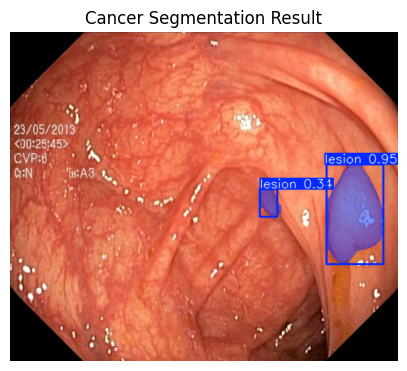

In [7]:
%matplotlib inline

from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# Load model
model = YOLO(
    r"C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\notebooks\training\runs\segment\train-8\weights\best.pt"
)

# Image path
image_path = r"C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\dataset\yolo_seg\images\train\0b792e26-e1dd-4fb7-a6b7-5d76f227a677.jpg"

# Predict
results = model.predict(image_path)

# Draw predictions
annotated_img = results[0].plot()

# Convert color
annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(5,5))
plt.imshow(annotated_img)
plt.title("Cancer Segmentation Result")
plt.axis("off")

plt.show()

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8m-seg.pt')

model.train(
    data=r'C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\dataset\yolo_seg\dataset.yaml',
    epochs=40,
    imgsz=512,
    batch=4,
    box=15.0,           # Tight boundary penalty double ki
    cls=2.0,            # Classification contrast separation badhaya
    overlap_mask=False, # Har irregular patch ko alag se target karega
    device=0
)

New https://pypi.org/project/ultralytics/8.4.60 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.46  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=15.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\dataset\yolo_seg\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=30

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000016D76F91C50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.0410

In [ ]:
segmenter = YOLO(r"C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\notebooks\training\runs\segment\train-11\weights\best.pt")


image 1/1 C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\dataset\yolo_seg\images\train\0b792e26-e1dd-4fb7-a6b7-5d76f227a677.jpg: 448x512 1 lesion, 117.1ms
Speed: 2.3ms preprocess, 117.1ms inference, 18.5ms postprocess per image at shape (1, 3, 448, 512)


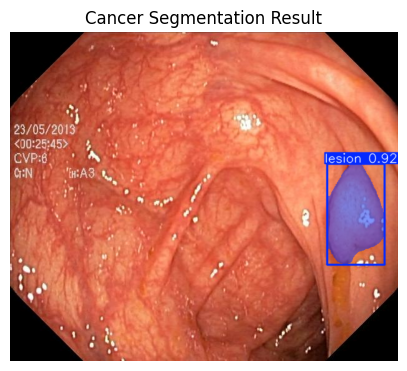

In [3]:
%matplotlib inline

from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# Load model
model = YOLO(
    r"C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\notebooks\training\runs\segment\train-11\weights\best.pt"
)

# Image path
image_path = r"C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\dataset\yolo_seg\images\train\0b792e26-e1dd-4fb7-a6b7-5d76f227a677.jpg"

# Predict
results = model.predict(image_path)

# Draw predictions
annotated_img = results[0].plot()

# Convert color
annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(5,5))
plt.imshow(annotated_img)
plt.title("Cancer Segmentation Result")
plt.axis("off")

plt.show()